# Прогнозирование перепада давления при стенозе с использованием машинного обучения на основе геометрических и гемодинамических параметров

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score
)

In [28]:
df = pd.read_csv('../data/data.csv', encoding='utf8', sep=';') 
df.head()

,Re,Stenosis length [cm],Radius [cm],Stenosis length/Radius,Degree of stenosis,Asymmetry,Pressure difference [dyn/cm^2]
0,30,0.75,0.15,5.0,0.0,1.0,97
1,50,0.75,0.15,5.0,0.0,1.0,156
2,100,0.75,0.15,5.0,0.0,1.0,314
3,200,0.75,0.15,5.0,0.0,1.0,623
4,300,0.75,0.15,5.0,0.0,1.0,939


## 2. Подготовка данных для обучения моделей

In [31]:
rho = 1.05
mu = 0.035

df["Velocity [cm/s]"] = df["Re"] * mu / (2 * rho * df["Radius [cm]"])
df["rho*Velocity^2"] = rho * df["Velocity [cm/s]"]**2
df['Pressure difference norm'] = df['Pressure difference [dyn/cm^2]']/df["rho*Velocity^2"]

In [32]:
df

,Re,Stenosis length [cm],Radius [cm],Stenosis length/Radius,Degree of stenosis,Asymmetry,Pressure difference [dyn/cm^2],Velocity [cm/s],rho*Velocity^2,Pressure difference norm
0,30,0.750,0.15,5.0,0.0,1.0,97,3.333333,11.666667,8.314286
1,50,0.750,0.15,5.0,0.0,1.0,156,5.555556,32.407407,4.813714
2,100,0.750,0.15,5.0,0.0,1.0,314,11.111111,129.629630,2.422286
3,200,0.750,0.15,5.0,0.0,1.0,623,22.222222,518.518519,1.201500
4,300,0.750,0.15,5.0,0.0,1.0,939,33.333333,1166.666667,0.804857
...,...,...,...,...,...,...,...,...,...,...
1795,400,0.375,0.15,2.5,0.9,0.0,10854026,44.444444,2074.074074,5233.191107
1796,500,0.375,0.15,2.5,0.9,0.0,16821563,55.555556,3240.740741,5190.653726
1797,600,0.375,0.15,2.5,0.9,0.0,25079284,66.666667,4666.666667,5374.132286
1798,700,0.375,0.15,2.5,0.9,0.0,33275563,77.777778,6351.851852,5238.718373


In [33]:
X = df.drop(['Pressure difference [dyn/cm^2]', 'Stenosis length [cm]', 'Radius [cm]', 'Velocity [cm/s]', 'rho*Velocity^2', 'Pressure difference norm'], axis=1)
y = df['Pressure difference norm']

In [34]:
df = pd.read_csv('../data/data4_2.csv',sep=',')
# eps = 1e-6
# Ds = df["Degree of stenosis"]
# Re = df["Re"]
# Lr = df["Stenosis length/Radius"]
# asym = df["Asymmetry"]

# df["As"] = 1 - (1 - Ds)**2
# df["area_ratio"] = 1 / ((1 - Ds)**2 + eps)

# df["Ds2"] = Ds**2
# df["Ds3"] = Ds**3

# df["log_Re"] = np.log(Re + eps)

# df["Lr_Ds"] = Lr * Ds
# df["Lr_area_ratio"] = Lr * df["area_ratio"]

# df["logRe_Ds"] = df["log_Re"] * Ds
# df["logRe_area_ratio"] = df["log_Re"] * df["area_ratio"]

# df["asym_Ds"] = asym * Ds
# df["asym_area_ratio"] = asym * df["area_ratio"]
X = df.drop(['Pressure difference'], axis=1)
y = df['Pressure difference']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X

,Re,Stenosis length/Radius,Degree of stenosis,Asymmetry
0,30,5.0,0.0,1.0
1,50,5.0,0.0,1.0
2,100,5.0,0.0,1.0
3,200,5.0,0.0,1.0
4,300,5.0,0.0,1.0
...,...,...,...,...
1795,400,2.5,0.9,0.0
1796,500,2.5,0.9,0.0
1797,600,2.5,0.9,0.0
1798,700,2.5,0.9,0.0


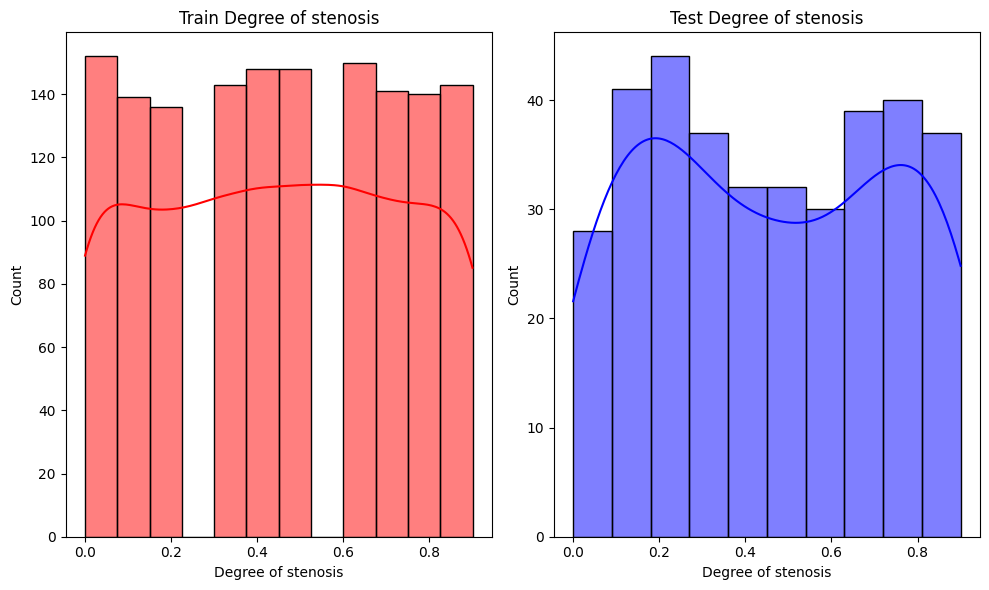

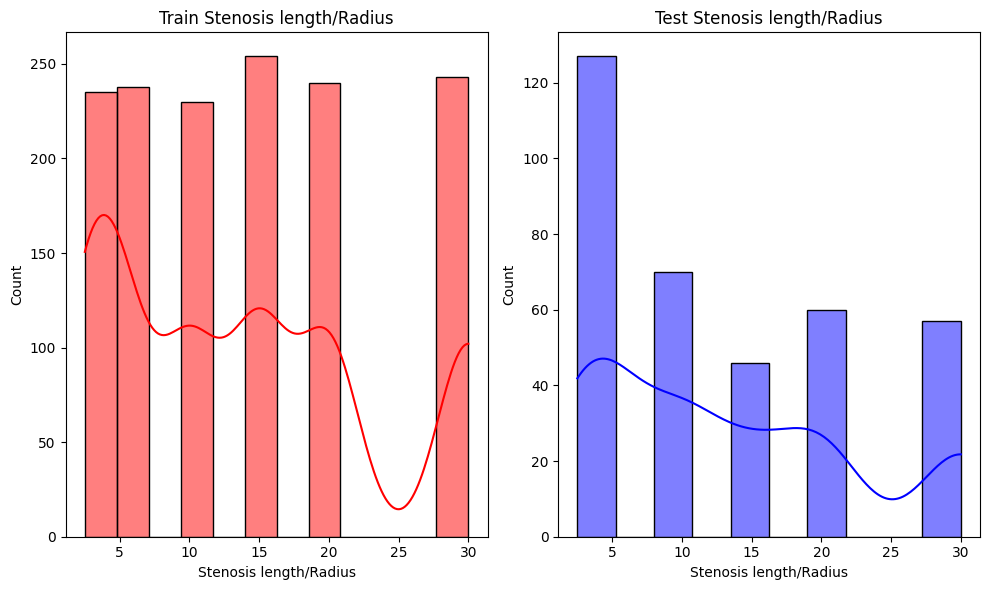

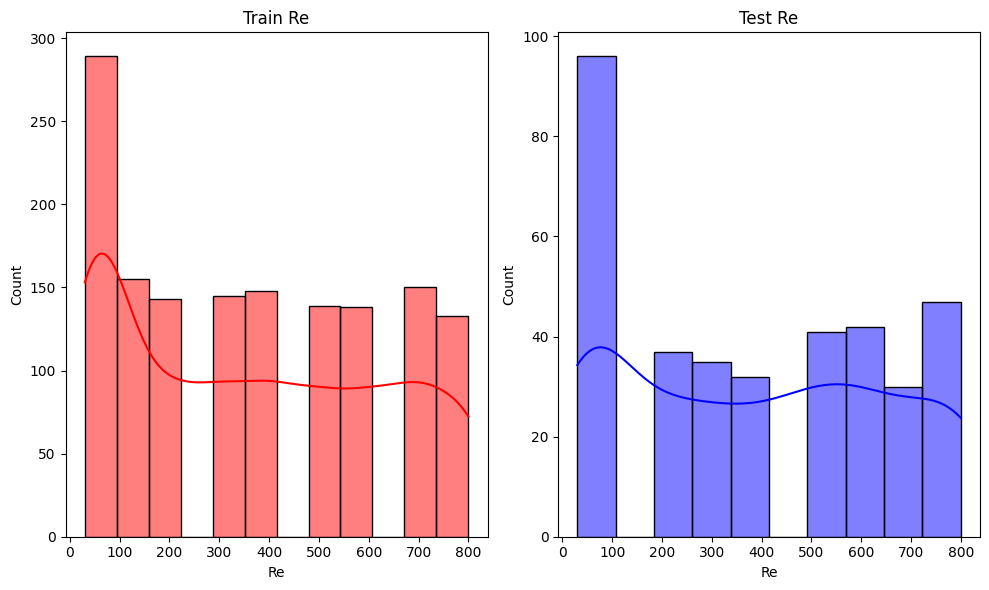

In [37]:
def train_test_plot(train, test, X):
    plt.figure(figsize=(10,6))

    plt.subplot(1,2,1)
    sns.histplot(train[X], kde=True, color ='red')
    plt.title(f'Train {X}')

    plt.subplot(1,2,2)
    sns.histplot(test[X], kde=True, color='blue')
    plt.title(f'Test {X}')

    plt.tight_layout()
    plt.show()

train_test_plot(X_train, X_test, 'Degree of stenosis')
train_test_plot(X_train, X_test, 'Stenosis length/Radius') 
train_test_plot(X_train, X_test, 'Re')


In [38]:
print('-' * 50)
print(f'Распределение в обучающей выборке {X_train["Degree of stenosis"].value_counts(normalize=True).sort_index()}')
print('-' * 50)
print(f'Распределение в тестовой выборке {X_test["Degree of stenosis"].value_counts(normalize=True).sort_index()}')
print('-' * 50)

--------------------------------------------------
Распределение в обучающей выборке Degree of stenosis
0.0    0.105556
0.1    0.096528
0.2    0.094444
0.3    0.099306
0.4    0.102778
0.5    0.102778
0.6    0.104167
0.7    0.097917
0.8    0.097222
0.9    0.099306
Name: proportion, dtype: float64
--------------------------------------------------
Распределение в тестовой выборке Degree of stenosis
0.0    0.077778
0.1    0.113889
0.2    0.122222
0.3    0.102778
0.4    0.088889
0.5    0.088889
0.6    0.083333
0.7    0.108333
0.8    0.111111
0.9    0.102778
Name: proportion, dtype: float64
--------------------------------------------------


In [39]:
print('-' * 50)
print(f'Распределение в обучающей выборке {X_train["Stenosis length/Radius"].value_counts(normalize=True).sort_index()}')
print('-' * 50)
print(f'Распределение в тестовой выборке {X_test["Stenosis length/Radius"].value_counts(normalize=True).sort_index()}')
print('-' * 50)

--------------------------------------------------
Распределение в обучающей выборке Stenosis length/Radius
2.5     0.163194
5.0     0.165278
10.0    0.159722
15.0    0.176389
20.0    0.166667
30.0    0.168750
Name: proportion, dtype: float64
--------------------------------------------------
Распределение в тестовой выборке Stenosis length/Radius
2.5     0.180556
5.0     0.172222
10.0    0.194444
15.0    0.127778
20.0    0.166667
30.0    0.158333
Name: proportion, dtype: float64
--------------------------------------------------


In [40]:
print('-' * 50)
print(f'Распределение в обучающей выборке {X_train["Re"].value_counts(normalize=True).sort_index()}')
print('-' * 50)
print(f'Распределение в тестовой выборке {X_test["Re"].value_counts(normalize=True).sort_index()}')
print('-' * 50)

--------------------------------------------------
Распределение в обучающей выборке Re
30     0.103472
50     0.097222
100    0.107639
200    0.099306
300    0.100694
400    0.102778
500    0.096528
600    0.095833
700    0.104167
800    0.092361
Name: proportion, dtype: float64
--------------------------------------------------
Распределение в тестовой выборке Re
30     0.086111
50     0.111111
100    0.069444
200    0.102778
300    0.097222
400    0.088889
500    0.113889
600    0.116667
700    0.083333
800    0.130556
Name: proportion, dtype: float64
--------------------------------------------------


In [41]:
cols = ['Re','Stenosis length/Radius','Degree of stenosis','Asymmetry']
train_keys = set(map(tuple, X_train[cols].to_numpy()))
test_keys  = set(map(tuple, X_test[cols].to_numpy()))
len(train_keys & test_keys), len(test_keys)


(0, 360)

* 0 — число совпадающих комбинаций параметров между train и test

* 360 — число уникальных комбинаций в test

## 3. Построение моделей

In [42]:
groups_train = (
    X_train['Degree of stenosis'].round(6).astype(str) + '_' +
    X_train['Stenosis length/Radius'].round(6).astype(str)
)
gkf = GroupKFold(n_splits=5)

In [43]:
def preprocessor(model, scale_X=False):
    log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True)

    numeric = [
    'Re',
    'Stenosis length/Radius',
    'Degree of stenosis',
    'Asymmetry',
]

    num_transformer = StandardScaler() if scale_X else 'passthrough'

    preprocessor = ColumnTransformer([
        ('num', num_transformer, numeric),
    ])

    regressor = TransformedTargetRegressor(
        regressor=model,
        transformer=log_transformer
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])
    return pipeline

In [44]:
def report_and_plots(y_train, train_pred, y_test, y_pred):
    # Метрики
    mae_train = mean_absolute_error(y_train, train_pred)
    mae_test  = mean_absolute_error(y_test,  y_pred)

    medae_train = median_absolute_error(y_train, train_pred)
    medae_test  = median_absolute_error(y_test,  y_pred)

    mse_train = mean_squared_error(y_train, train_pred)
    mse_test  = mean_squared_error(y_test,  y_pred)

    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)

    mean_abs_test = np.mean(np.abs(y_test))
    nmae_test = 100 * mae_test / mean_abs_test

    r2 = r2_score(y_test, y_pred)

    print(f"MAE (обучение) = {mae_train:,.0f}")
    print(f"MAE (тест)     = {mae_test:,.0f}")
    print(f"MedianAE (обучение)= {medae_train:,.0f}")
    print(f"MedianAE (тест)= {medae_test:,.0f}")
    print(f"MSE (обучение) = {mse_train:,.0f}")
    print(f"MSE (тест)     = {mse_test:,.0f}")
    print(f"RMSE (обучение)= {rmse_train:,.0f}")
    print(f"RMSE (тест)    = {rmse_test:,.0f}")
    print(f"Отн. ошибка (MAE/mean|y|) на тесте = {nmae_test:.2f}%")
    print(f"R² (тест) = {r2:.4f}")

    # --- График 1: столбики MAE train/test ---
    plt.figure()
    plt.bar(["Обучение", "Тест"], [mae_train, mae_test])
    plt.ylabel("MAE (абс. ошибка)")
    plt.title("Ошибка на обучении и тесте")
    plt.show()

    # --- График 2: y_true vs y_pred ---
    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.6)
    mn = min(np.min(y_test), np.min(y_pred))
    mx = max(np.max(y_test), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Истинное значение")
    plt.ylabel("Предсказание")
    plt.title("Истинное vs предсказанное (тест)")
    plt.show()

    # --- График 3: распределение абсолютной ошибки ---
    abs_err = np.abs(y_test - y_pred)
    plt.figure()
    plt.hist(abs_err, bins=30)
    plt.xlabel("|Ошибка|")
    plt.ylabel("Количество примеров")
    plt.title("Распределение абсолютной ошибки (тест)")
    plt.show()

In [45]:
def run_model(model, scale_X=False):
    pipeline = preprocessor(model, scale_X=scale_X)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    train_pred = pipeline.predict(X_train)

    report_and_plots(y_train, train_pred, y_test, y_pred)

    regressor_step = pipeline.named_steps['regressor']
    regressor_fitted = getattr(regressor_step, 'regressor_', regressor_step)

    names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    names = pd.Series(names).str.replace('num__', '', regex=False)

    # Для деревьев / леса / XGBoost
    if hasattr(regressor_fitted, 'feature_importances_'):
        importance = pd.DataFrame({
            'feature': names,
            'importance': regressor_fitted.feature_importances_
        }).sort_values(by='importance', ascending=False)

        print("\nВажность признаков:")
        print(importance)

    # Для линейной регрессии
    elif hasattr(regressor_fitted, 'coef_'):
        coef_df = pd.DataFrame({
            'feature': names,
            'coefficient': regressor_fitted.coef_
        }).sort_values(by='coefficient', key=lambda s: s.abs(), ascending=False)

        print("\nКоэффициенты признаков:")
        print(coef_df)
        print(f"\nIntercept: {regressor_fitted.intercept_}")

    else:
        print("\nУ этой модели нет feature_importances_ или coef_")

    return pipeline

### 3.1. Линейная регрессия

In [46]:
# def linear_model(fit_intercept=True):
#     model_lr = LinearRegression(
#         fit_intercept=fit_intercept
#     )

#     model_lr_pip = run_model(model_lr, scale_X=True)
#     return model_lr_pip

In [47]:
from sklearn.linear_model import Ridge

def linear_model(alpha=1.0):
    model_lr = Ridge(alpha=alpha)
    model_lr_pip = run_model(model_lr, scale_X=True)
    return model_lr_pip

### 3.2. Метод ближайших соседей (knn)

In [48]:
# def knn_model(n_neighbors=8, weights='distance', p=2):
#     model_knn = KNeighborsRegressor(
#         n_neighbors=n_neighbors,
#         weights=weights,
#         p=p
#     )

#     model_knn_pip = run_model(model_knn, scale_X=True)
#     return model_knn_pip

In [49]:
def knn_model(
    n_neighbors=7,
    weights='distance',
    p=3,
    algorithm='auto',
    leaf_size=100,
    metric='minkowski'
):
    model_knn = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        algorithm=algorithm,
        leaf_size=leaf_size,
        metric=metric
    )

    model_knn_pip = run_model(model_knn, scale_X=True)
    return model_knn_pip

### 3.3. Градиентный бустинг

In [50]:
def gradient_boosting_model(loss, learning_rate, n_estimators, max_depth, min_samples_leaf, subsample):
    model_gbr = GradientBoostingRegressor(
        loss=loss,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=42,
    )
    model_gbr_pip = run_model(model_gbr,scale_X=False)
    return model_gbr_pip


### 3.4. XGBoost

In [51]:
def XGBR_model(learning_rate, n_estimators, max_depth, min_child_weight,
              subsample, colsample_bytree, reg_lambda, reg_alpha):

    model_xgbr = XGBRegressor(
        objective='reg:squarederror',
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        random_state=42,
    )

    model_xgbr_pip = run_model(model_xgbr,scale_X=False)
    return model_xgbr_pip


### 3.5. Случайный лес

In [52]:
def random_forest_model(n_estimators, max_depth, min_samples_leaf, max_features, bootstrap=True):
    model_rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        oob_score=bootstrap,  # OOB работает только если bootstrap=True
        random_state=42,
        n_jobs=-1,
    )

    model_rf_pip = run_model(model_rf,scale_X=False)
    return model_rf_pip


## 4. Поиск гиперпараметров с помощью GridSearch

In [53]:
X_test

,Re,Stenosis length/Radius,Degree of stenosis,Asymmetry
1591,50,2.5,0.8,1.0
943,200,2.5,0.5,0.5
869,800,20.0,0.4,0.0
162,100,30.0,0.0,0.5
1271,50,5.0,0.7,0.5
...,...,...,...,...
765,400,2.5,0.4,0.5
1465,50,20.0,0.8,0.0
1734,300,10.0,0.9,0.0
1269,800,5.0,0.7,1.0


MAE (обучение) = 737
MAE (тест)     = 717
MedianAE (обучение)= 15
MedianAE (тест)= 12
MSE (обучение) = 6,480,163
MSE (тест)     = 5,891,106
RMSE (обучение)= 2,546
RMSE (тест)    = 2,427
Отн. ошибка (MAE/mean|y|) на тесте = 81.91%
R² (тест) = 0.1630


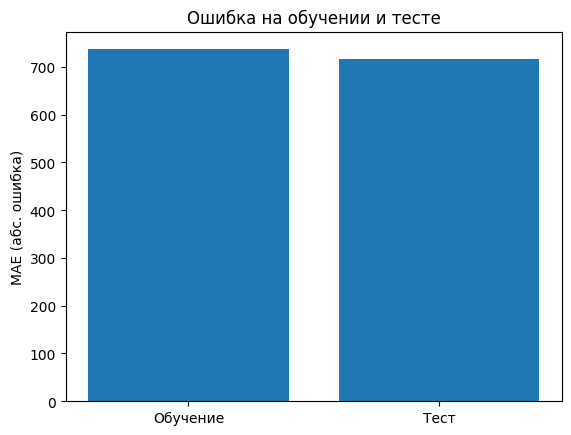

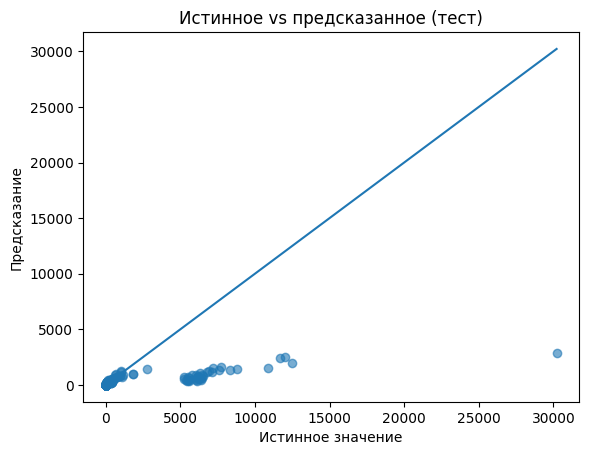

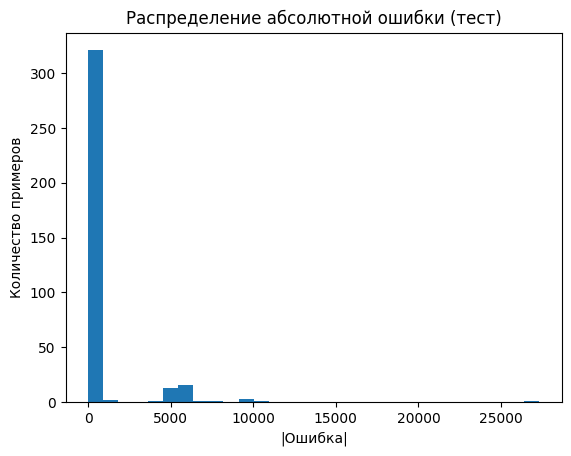


Коэффициенты признаков:
                  feature  coefficient
2      Degree of stenosis     2.228338
0                      Re    -0.488979
1  Stenosis length/Radius     0.269350
3               Asymmetry     0.049668

Intercept: 3.3846117755202485


In [54]:
lr_model = linear_model()

MAE (обучение) = 0
MAE (тест)     = 589
MedianAE (обучение)= 0
MedianAE (тест)= 2
MSE (обучение) = 0
MSE (тест)     = 4,083,721
RMSE (обучение)= 0
RMSE (тест)    = 2,021
Отн. ошибка (MAE/mean|y|) на тесте = 67.32%
R² (тест) = 0.4198


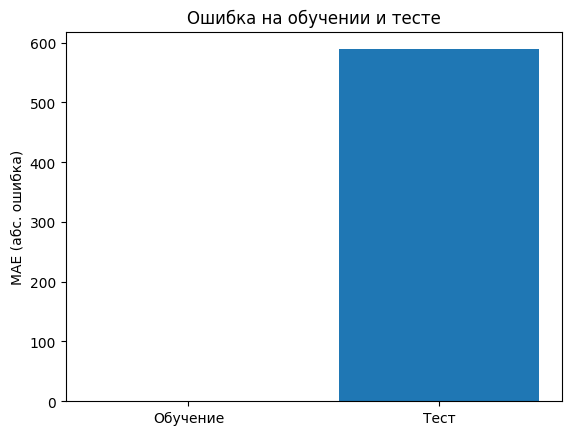

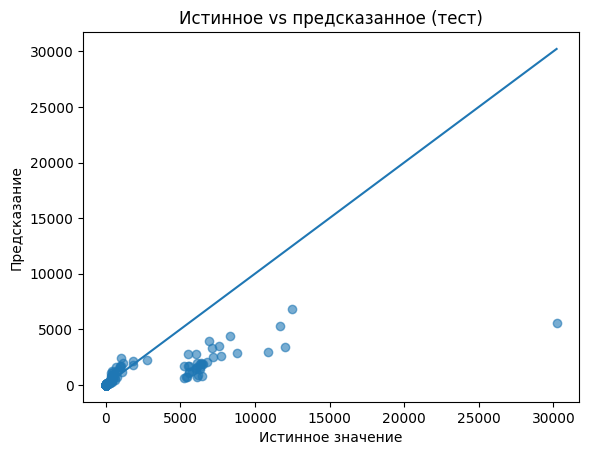

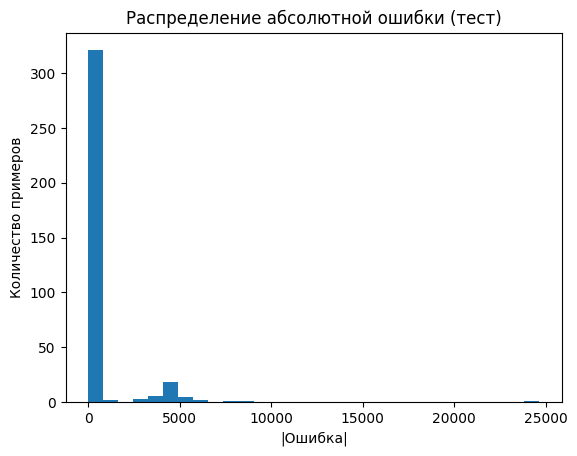


У этой модели нет feature_importances_ или coef_


In [55]:
model_knn_pip = knn_model() 

In [56]:
def gridsearch(pipeline, param_grid, model):

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        scoring='neg_mean_absolute_error',
        cv=gkf,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best = grid_search.best_params_
    print("Найденные параметры:", best)

    if model == 1:
        gradient_boosting_model(
            loss=best['regressor__regressor__loss'],
            learning_rate=best['regressor__regressor__learning_rate'],
            n_estimators=best['regressor__regressor__n_estimators'],
            max_depth=best['regressor__regressor__max_depth'],
            min_samples_leaf=best['regressor__regressor__min_samples_leaf'],
            subsample=best['regressor__regressor__subsample'],
        )

    elif model == 2:
        XGBR_model(
            learning_rate=best['regressor__regressor__learning_rate'],
            n_estimators=best['regressor__regressor__n_estimators'],
            max_depth=best['regressor__regressor__max_depth'],
            min_child_weight=best['regressor__regressor__min_child_weight'],
            reg_lambda=best['regressor__regressor__reg_lambda'],
            subsample=best['regressor__regressor__subsample'],
            colsample_bytree=best['regressor__regressor__colsample_bytree'],
            reg_alpha=best['regressor__regressor__reg_alpha'],
        )

    elif model == 3:
        random_forest_model(
            n_estimators=best['regressor__regressor__n_estimators'],
            max_depth=best['regressor__regressor__max_depth'],
            min_samples_leaf=best['regressor__regressor__min_samples_leaf'],
            max_features=best['regressor__regressor__max_features'],
            bootstrap=best['regressor__regressor__bootstrap'],
        )


    return grid_search


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Найденные параметры: {'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__loss': 'huber', 'regressor__regressor__max_depth': 3, 'regressor__regressor__min_samples_leaf': 20, 'regressor__regressor__n_estimators': 800, 'regressor__regressor__subsample': 0.8}
MAE (обучение) = 18
MAE (тест)     = 28
MedianAE (обучение)= 0
MedianAE (тест)= 0
MSE (обучение) = 6,131
MSE (тест)     = 13,084
RMSE (обучение)= 78
RMSE (тест)    = 114
Отн. ошибка (MAE/mean|y|) на тесте = 3.15%
R² (тест) = 0.9981


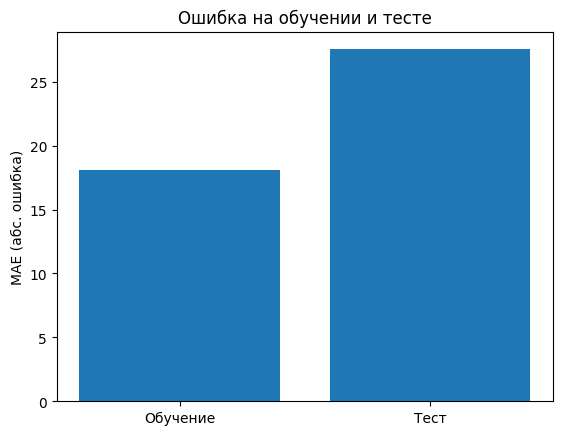

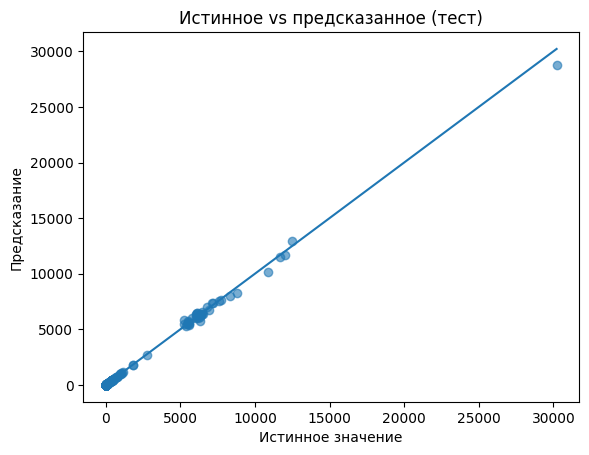

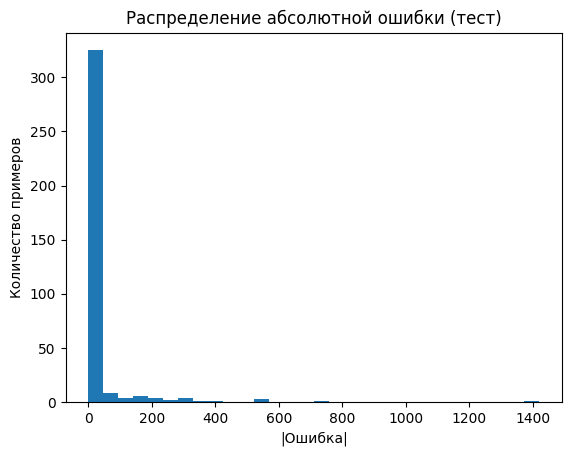


Важность признаков:
                  feature  importance
2      Degree of stenosis    0.926495
0                      Re    0.060154
1  Stenosis length/Radius    0.013072
3               Asymmetry    0.000279


In [57]:
base_gbr_model = GradientBoostingRegressor(random_state=42) # Создаем базовый объект
pipeline_gbr = preprocessor(base_gbr_model)

param_grid_gdr = {
  'regressor__regressor__loss': ['huber', 'squared_error'],
  'regressor__regressor__learning_rate': [0.1, 0.05, 0.03],
  'regressor__regressor__n_estimators': [200, 400, 800],
  'regressor__regressor__max_depth': [2, 3, 4],
  'regressor__regressor__min_samples_leaf': [5, 10, 20, 50],
  'regressor__regressor__subsample': [0.6, 0.8, 1.0],
}


gs_gbr = gridsearch(pipeline_gbr, param_grid_gdr, 1)

Fitting 5 folds for each of 11664 candidates, totalling 58320 fits
Найденные параметры: {'regressor__regressor__colsample_bytree': 1.0, 'regressor__regressor__learning_rate': 0.03, 'regressor__regressor__max_depth': 3, 'regressor__regressor__min_child_weight': 8, 'regressor__regressor__n_estimators': 2000, 'regressor__regressor__reg_alpha': 0, 'regressor__regressor__reg_lambda': 1, 'regressor__regressor__subsample': 0.7}
MAE (обучение) = 18
MAE (тест)     = 24
MedianAE (обучение)= 0
MedianAE (тест)= 0
MSE (обучение) = 4,651
MSE (тест)     = 7,999
RMSE (обучение)= 68
RMSE (тест)    = 89
Отн. ошибка (MAE/mean|y|) на тесте = 2.69%
R² (тест) = 0.9989


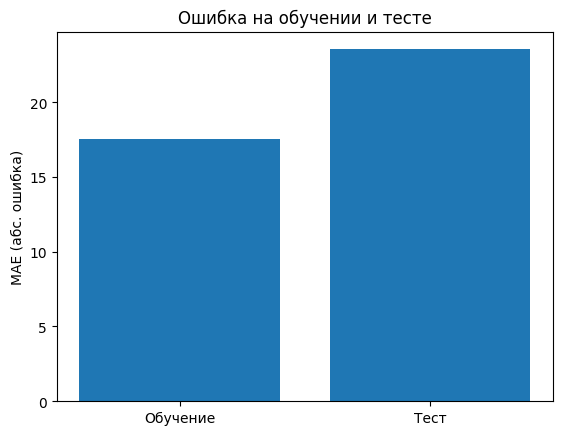

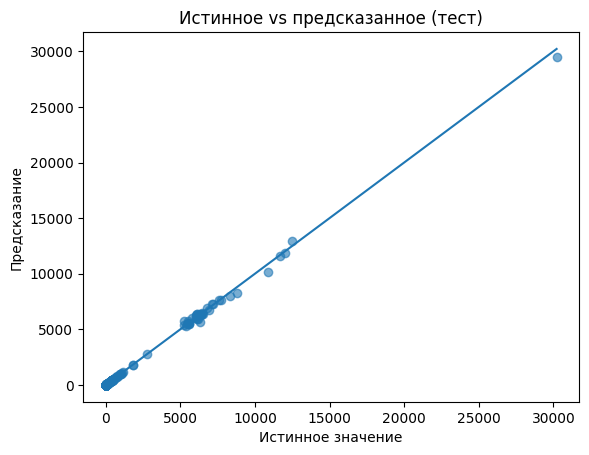

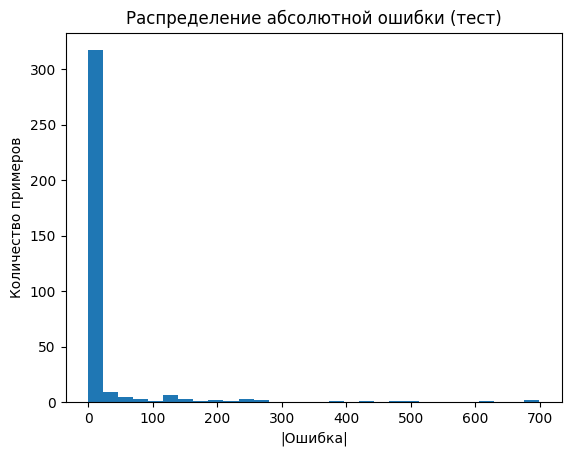


Важность признаков:
                  feature  importance
2      Degree of stenosis    0.893345
0                      Re    0.087152
1  Stenosis length/Radius    0.018027
3               Asymmetry    0.001477


In [58]:
base_xgbr_model = XGBRegressor( objective='reg:squarederror', random_state=42, reg_lambda=100.0 )

pipeline_xgbr = preprocessor(base_xgbr_model)

param_grid_xgbr = {
  'regressor__regressor__learning_rate': [0.1, 0.05, 0.03],
  'regressor__regressor__n_estimators': [500, 1000, 2000],
  'regressor__regressor__max_depth': [2, 3, 4, 5],
  'regressor__regressor__min_child_weight': [1, 3, 5, 8],
  'regressor__regressor__subsample': [0.7, 0.9, 1.0],
  'regressor__regressor__colsample_bytree': [0.7, 0.9, 1.0],
  'regressor__regressor__reg_lambda': [1, 10, 100],
  'regressor__regressor__reg_alpha': [0, 0.1, 1.0],
}

gs_xgbr = gridsearch(pipeline_xgbr, param_grid_xgbr, 2)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Найденные параметры: {'regressor__regressor__bootstrap': True, 'regressor__regressor__max_depth': None, 'regressor__regressor__max_features': 1.0, 'regressor__regressor__min_samples_leaf': 1, 'regressor__regressor__n_estimators': 1000}
MAE (обучение) = 16
MAE (тест)     = 35
MedianAE (обучение)= 0
MedianAE (тест)= 0
MSE (обучение) = 9,090
MSE (тест)     = 26,241
RMSE (обучение)= 95
RMSE (тест)    = 162
Отн. ошибка (MAE/mean|y|) на тесте = 3.99%
R² (тест) = 0.9963


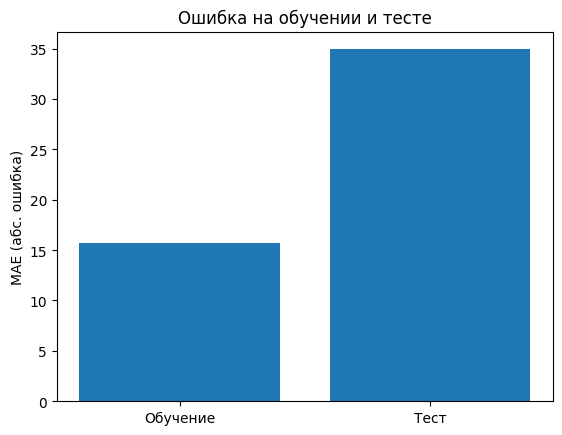

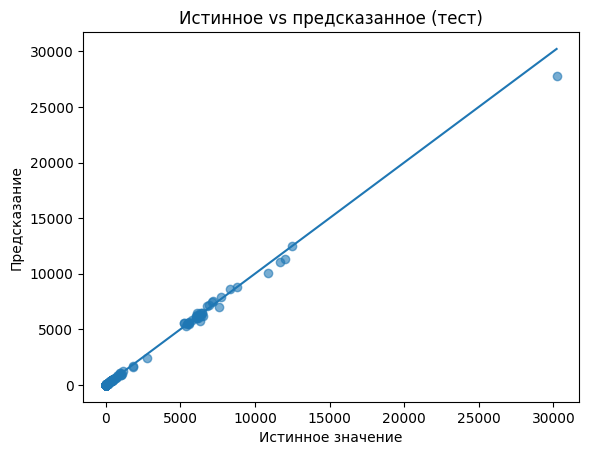

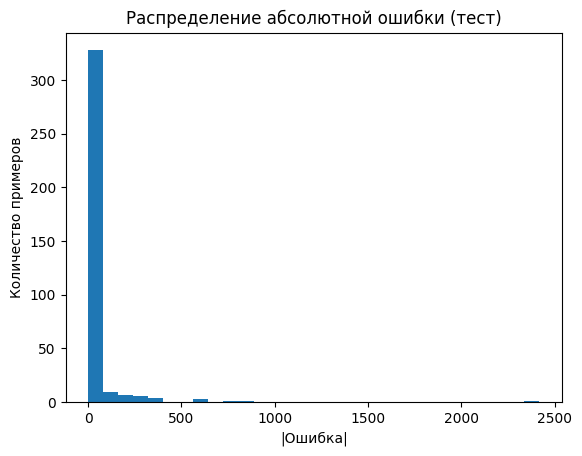


Важность признаков:
                  feature  importance
2      Degree of stenosis    0.928302
0                      Re    0.056797
1  Stenosis length/Radius    0.014519
3               Asymmetry    0.000381


In [59]:
base_rfr_model = RandomForestRegressor(random_state=42) 
pipeline_rfr = preprocessor(base_rfr_model) 
param_grid_rfr = {
  'regressor__regressor__n_estimators': [300, 600, 1000],
  'regressor__regressor__max_depth': [6, 10, 15, None],
  'regressor__regressor__min_samples_leaf': [1, 2, 5, 10, 20],
  'regressor__regressor__max_features': ['sqrt', 0.5, 0.8, 1.0],
  'regressor__regressor__bootstrap': [True],
}


gs_rfr = gridsearch(pipeline_rfr, param_grid_rfr, 3)

In [60]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

all_models = {
    "lr": lr_model,
    "knn": model_knn_pip,
    "gbr": gs_gbr.best_estimator_,
    "xgb": gs_xgbr.best_estimator_,
    "rf":  gs_rfr.best_estimator_,
}

joblib.dump(all_models, "../models/all_models2.joblib")
print("Модели сохранены в ../models/all_models2.joblib")

Модели сохранены в ../models/all_models2.joblib


In [61]:
df_test = pd.read_csv("../data/data_test2.csv", sep=",")

# если колонка подписана старым именем, но уже хранит norm:
df_test = df_test.rename(columns={'Pressure difference': 'Pressure difference norm'})

feature_cols = ['Re', 'Stenosis length/Radius', 'Degree of stenosis', 'Asymmetry']
target_col = 'Pressure difference norm'

X_test = df_test[feature_cols].copy()
all_models = joblib.load("../models/all_models2.joblib")

eps = 1e-12
metrics_rows = []

for name, model in all_models.items():
    y_pred = np.asarray(model.predict(X_test)).reshape(-1)
    df_test[f"pred_{name}"] = y_pred

    if target_col in df_test.columns:
        y_true = df_test[target_col].to_numpy()

        valid_mask = np.isfinite(y_true) & np.isfinite(y_pred)
        y_true_valid = y_true[valid_mask]
        y_pred_valid = y_pred[valid_mask]

        mae = np.mean(np.abs(y_true_valid - y_pred_valid))
        rmse = np.sqrt(np.mean((y_true_valid - y_pred_valid) ** 2))
        r2 = r2_score(y_true_valid, y_pred_valid)
        wape = mae / (np.mean(np.abs(y_true_valid)) + eps) * 100
        smape = np.mean(
            2 * np.abs(y_true_valid - y_pred_valid) /
            (np.abs(y_true_valid) + np.abs(y_pred_valid) + eps)
        ) * 100

        metrics_rows.append({
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "WAPE_%": wape,
            "sMAPE_%": smape
        })

df_metrics = pd.DataFrame(metrics_rows).sort_values("RMSE")
print(df_metrics.round(4))

  model      R2      MAE     RMSE    WAPE_%  sMAPE_%
1   knn  0.9015   8.9839  19.3904   19.6373  15.2050
2   gbr  0.7169  21.8908  32.8777   47.8495  33.3878
4    rf  0.7069  22.4193  33.4532   49.0046  33.6006
3   xgb  0.5866  22.1931  39.7327   48.5102  49.1597
0    lr -0.3947  46.8777  72.9767  102.4665  70.3566
